Experiment: nestedclinbr_mmbert_baseline
PR metrics:
Macro PR-AUC: 0.640 ± 0.034
Micro PR-AUC: 0.506 ± 0.020
Macro F1: 0.602 ± 0.027
Micro F1: 0.601 ± 0.020


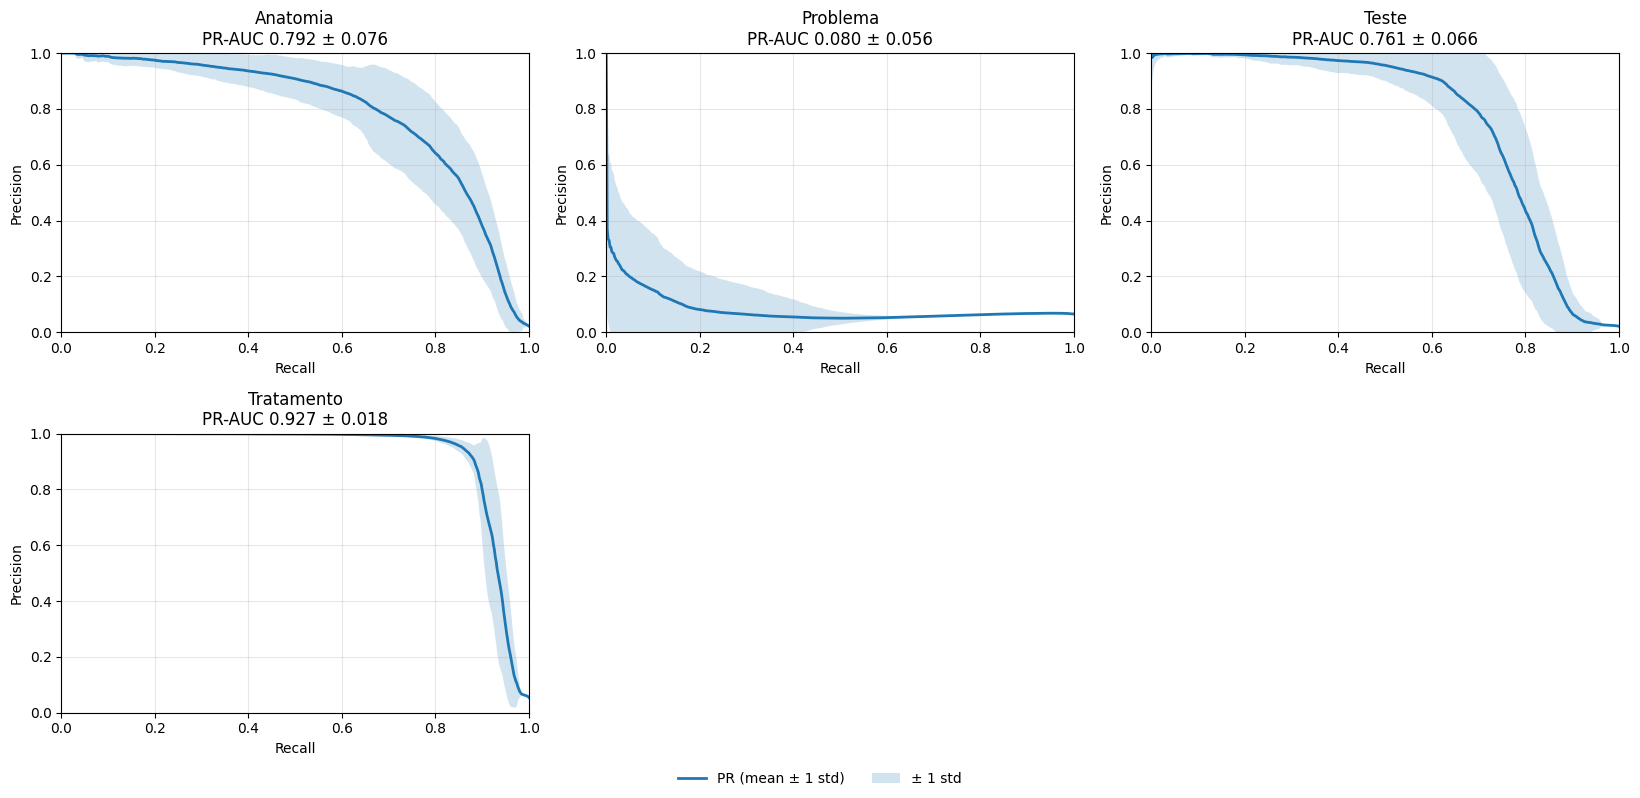

Experiment: nestedclinbr_mmbert_mecla
PR metrics:
Macro PR-AUC: 0.617 ± 0.043
Micro PR-AUC: 0.504 ± 0.024
Macro F1: 0.581 ± 0.039
Micro F1: 0.591 ± 0.028


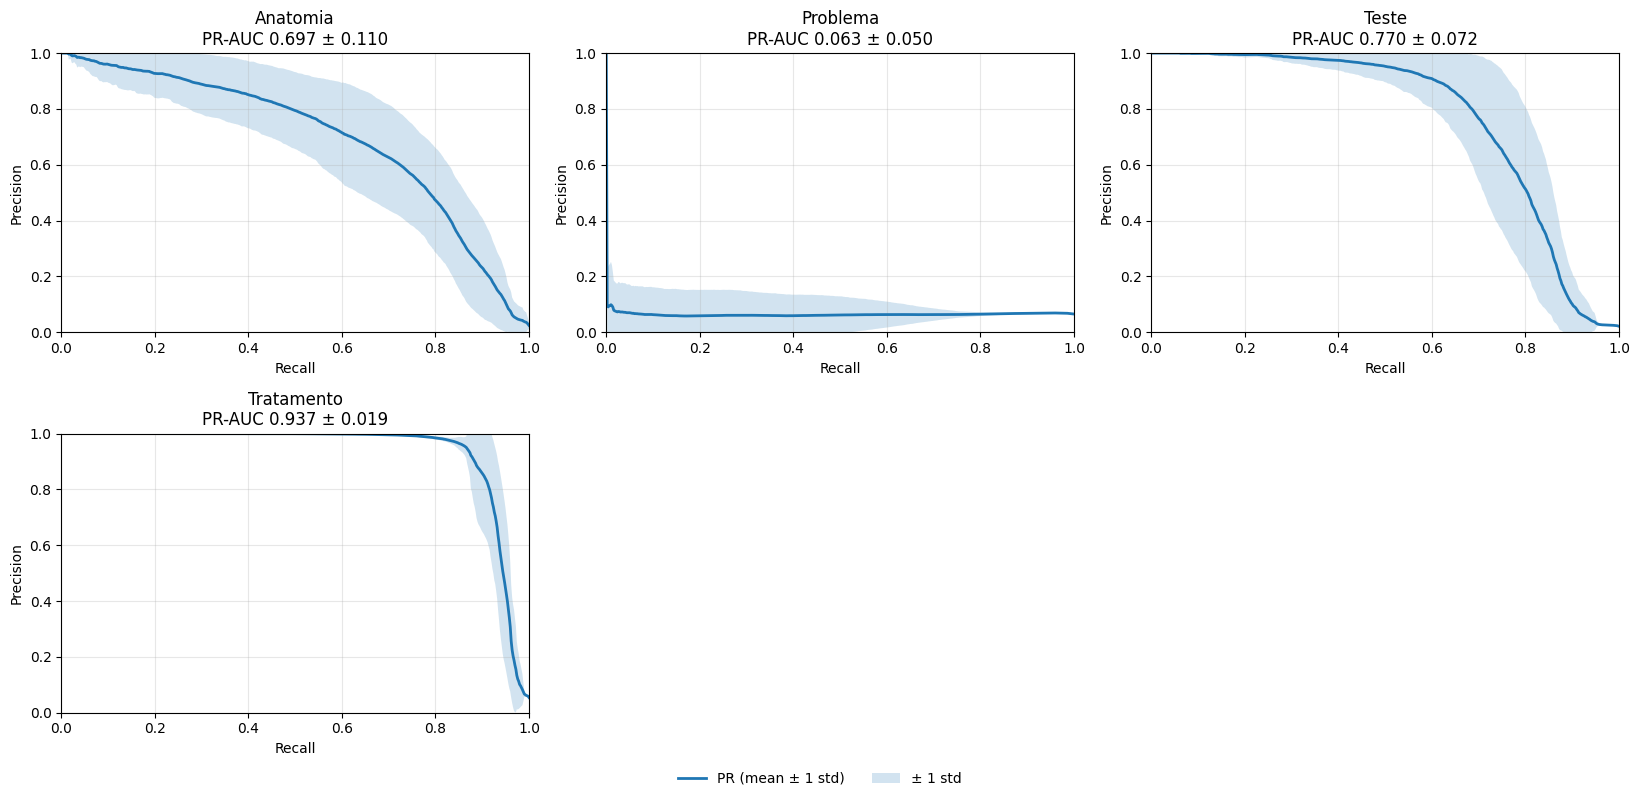

In [1]:
import pandas as pd
import jsonlines
from pathlib import Path
import math
import numpy as np
import matplotlib.pyplot as plt


def _compute_pr_mean_std(
    precisions_list: list[list[float]],
    recalls_list: list[list[float]],
    n_grid: int = 500,
    clip_to_unit: bool = True,
) -> tuple[np.ndarray, np.ndarray, np.ndarray, np.ndarray]:
    """
    Compute mean Precision-Recall curve with ±1 std bands on a common recall grid.

    Returns
    -------
    recall_grid : np.ndarray, shape (n_grid,)
    mean_p      : np.ndarray, shape (n_grid,)
    lower       : np.ndarray, shape (n_grid,)
    upper       : np.ndarray, shape (n_grid,)
    """
    if len(precisions_list) != len(recalls_list):
        raise ValueError("Mismatch runs count")

    recall_grid = np.linspace(0.0, 1.0, n_grid)
    interp_precisions: list[np.ndarray] = []

    for p, r in zip(precisions_list, recalls_list):
        p = np.asarray(p, dtype=float)
        r = np.asarray(r, dtype=float)

        # 1) sort by recall
        order = np.argsort(r)
        r = r[order]
        p = p[order]

        # 2) collapse duplicate recalls by max precision
        uniq_r, inv = np.unique(r, return_inverse=True)
        max_p = np.full_like(uniq_r, -np.inf, dtype=float)
        for i, idx in enumerate(inv):
            max_p[idx] = max(max_p[idx], p[i])
        r, p = uniq_r, max_p

        # 3) pad endpoints to cover [0,1]
        if r[0] > 0:
            r = np.insert(r, 0, 0.0)
            p = np.insert(p, 0, p[0])
        if r[-1] < 1:
            r = np.append(r, 1.0)
            p = np.append(p, p[-1])

        # 4) interpolate
        p_interp = np.interp(recall_grid, r, p)
        interp_precisions.append(p_interp)

    interp_precisions = np.vstack(interp_precisions)  # (n_runs, n_grid)

    mean_p = interp_precisions.mean(axis=0)
    std_p = (
        interp_precisions.std(axis=0, ddof=1)
        if interp_precisions.shape[0] > 1
        else np.zeros_like(mean_p)
    )

    lower = mean_p - std_p
    upper = mean_p + std_p

    if clip_to_unit:
        mean_p = np.clip(mean_p, 0, 1)
        lower = np.clip(lower, 0, 1)
        upper = np.clip(upper, 0, 1)

    return recall_grid, mean_p, lower, upper


def plot_pr_mean_std_grid(
    df,
    *,
    n_grid: int = 500,
    clip_to_unit: bool = True,
    ncols: int | None = None,
    figsize_per_ax: tuple[float, float] = (5.5, 4.0),
    curve_label: str = "PR (mean ± 1 std)",
):
    """
    Plot all labels' mean PR curves in a single grid of subplots, preserving the original logic.

    Assumes df['threshold_map'][i][label] contains:
      - 'precision': array-like
      - 'recall': array-like
      - 'pr_auc': float
    """
    labels = list(df["threshold_map"][0].keys())
    n_plots = len(labels)

    if ncols is None:
        # nice-ish default: up to 3 columns
        ncols = min(3, n_plots)
    nrows = math.ceil(n_plots / ncols)

    figsize = (figsize_per_ax[0] * ncols, figsize_per_ax[1] * nrows)
    fig, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=figsize, squeeze=False)
    axes_flat = axes.ravel()

    for ax, label in zip(axes_flat, labels):
        pr_aucs = np.asarray(
            [df["threshold_map"][i][label]["pr_auc"] for i in range(len(df["threshold_map"]))]
        )
        title = (
            f"{label}\n"
            f"PR-AUC {pr_aucs.mean():.3f} ± {pr_aucs.std():.3f}"
        )

        precisions = [df["threshold_map"][i][label]["precision"] for i in range(len(df["threshold_map"]))]
        recalls = [df["threshold_map"][i][label]["recall"] for i in range(len(df["threshold_map"]))]

        recall_grid, mean_p, lower, upper = _compute_pr_mean_std(
            precisions,
            recalls,
            n_grid=n_grid,
            clip_to_unit=clip_to_unit,
        )

        ax.plot(recall_grid, mean_p, linewidth=2, label=curve_label)
        ax.fill_between(recall_grid, lower, upper, alpha=0.2, label="± 1 std")
        ax.set_xlabel("Recall")
        ax.set_ylabel("Precision")
        ax.set_xlim(0, 1)
        ax.set_ylim(0, 1)
        ax.set_title(title)
        ax.grid(True, alpha=0.3)

    # Hide unused axes if grid is bigger than n_plots
    for ax in axes_flat[n_plots:]:
        ax.axis("off")

    # One shared legend (optional); comment out if you prefer per-plot legends.
    handles, labels_ = axes_flat[0].get_legend_handles_labels()
    if handles:
        fig.legend(handles, labels_, loc="lower center", ncol=2, frameon=False)

    fig.tight_layout(rect=(0, 0.03, 1, 1))  # leave space for shared legend
    plt.show()

models = ['mmbert']
experiments = ['baseline', 'mecla']
eval_metrics = ['eval_macro_pr_auc', 'eval_micro_pr_auc', 'eval_micro_f1', 'eval_macro_f1']

group_metrics_for_hypothesis_test = {}

for model in models:
    group_metrics_for_hypothesis_test[model] = {}
    for exp in experiments:
        experiments_to_evaluate = list(Path(f'experiments/nestedclinbr_{model}_{exp}').glob('**/metrics_*.jsonl'))
        metrics = []
        for experiment_path in experiments_to_evaluate:
            with jsonlines.open(experiment_path) as reader:
                for obj in reader:
                    metrics.append(obj)

        df = pd.DataFrame(metrics)
        
        group_metrics_for_hypothesis_test[model][exp] = {}
        for metric in eval_metrics:
            group_metrics_for_hypothesis_test[model][exp][metric] = df[metric].to_list()

        print(f'Experiment: nestedclinbr_{model}_{exp}')
        print('PR metrics:')
        print(f"Macro PR-AUC: {df['eval_macro_pr_auc'].mean():.3f} ± {df['eval_macro_pr_auc'].std():.3f}")
        print(f"Micro PR-AUC: {df['eval_micro_pr_auc'].mean():.3f} ± {df['eval_micro_pr_auc'].std():.3f}")
        print(f"Macro F1: {df['eval_macro_f1'].mean():.3f} ± {df['eval_macro_f1'].std():.3f}")
        print(f"Micro F1: {df['eval_micro_f1'].mean():.3f} ± {df['eval_micro_f1'].std():.3f}")
        plot_pr_mean_std_grid(df)


In [2]:
from scipy import stats
from itertools import combinations
from cliffs_delta import cliffs_delta
from statsmodels.stats.multitest import multipletests

for model in models:
    for metric in eval_metrics:
        print(f'Model: {model}')
        print(f'Metric: {metric}')

        # Perform the Friedman test
        metrics_data = [
                group_metrics_for_hypothesis_test[model][exp][metric]
                for exp in experiments
            ]
        for exp in experiments:
            print(len(group_metrics_for_hypothesis_test[model][exp][metric]))
        statistic, pvalue = stats.friedmanchisquare(
            *[
                group_metrics_for_hypothesis_test[model][exp][metric]
                for exp in experiments
            ]
        )

        print(f"Friedman test statistic: {statistic}")
        print(f"P-value: {pvalue:.5f}")
        print("=="*20)

        # Generate combinations of length 2
        combos_iterator = combinations(experiments, 2)

        # Convert the iterator to a list of tuples for display
        combos_list = list(combos_iterator)
        print('Combinations')
        print(combos_list)
        print("=="*20)
        # post hoc with Wilcoxon Signed-Rank Test for each pair and Cliff's Delta
        p_values = []
        test_results = []
        for group1, group2 in combos_list:
            stat, p = stats.wilcoxon(
                group_metrics_for_hypothesis_test[model][group1][metric],
                group_metrics_for_hypothesis_test[model][group2][metric]
                )
            p_values.append(p)
            test_results.append({'Comparison': f"{group1} vs {group2}", 'Raw P-Value': p})
            d, size = cliffs_delta(
                group_metrics_for_hypothesis_test[model][group1][metric], group_metrics_for_hypothesis_test[model][group2][metric]
                )
            
            print(f"Comparison: {group1} vs {group2}")
            print(f"Cliff's Delta: {d}")
            print(f"Effect size: {size}")
            print("=="*20)

        reject, corrected_p, _, _ = multipletests(p_values, alpha=0.05, method='bonferroni')
        results_df = pd.DataFrame(test_results)
        results_df['Corrected P-Value'] = corrected_p
        results_df['Reject H0'] = reject
        print(results_df)

        print('\n\n')

Model: mmbert
Metric: eval_macro_pr_auc
30
30


ValueError: At least 3 samples must be given for Friedman test, got 2.

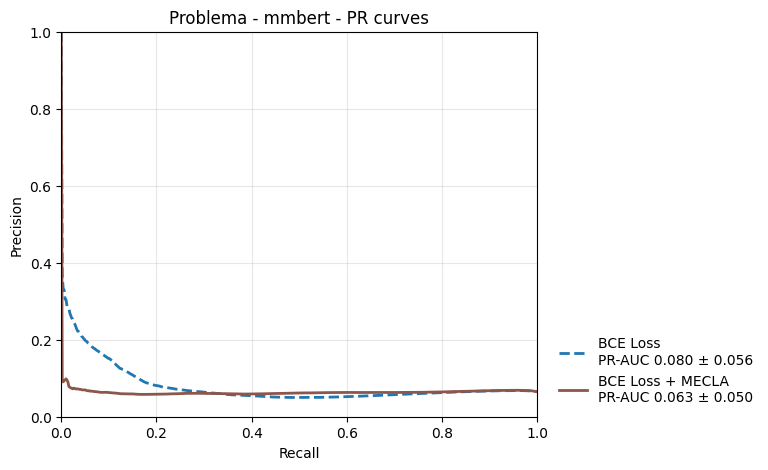

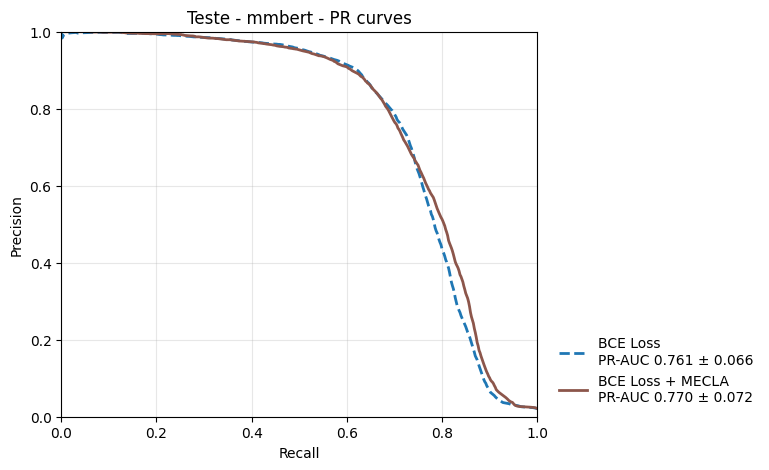

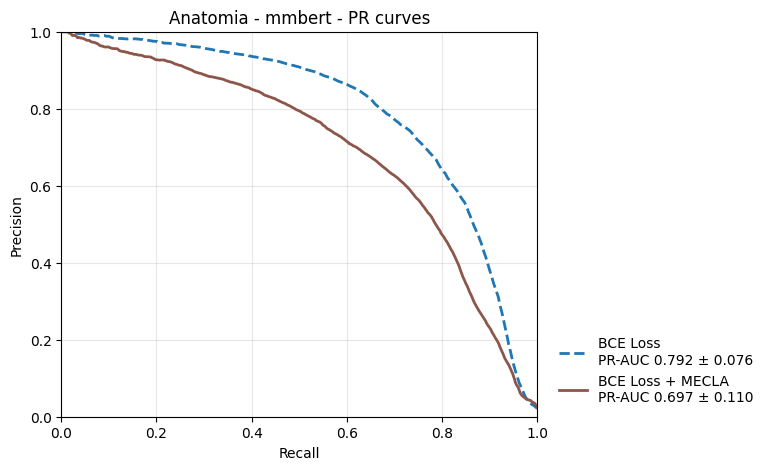

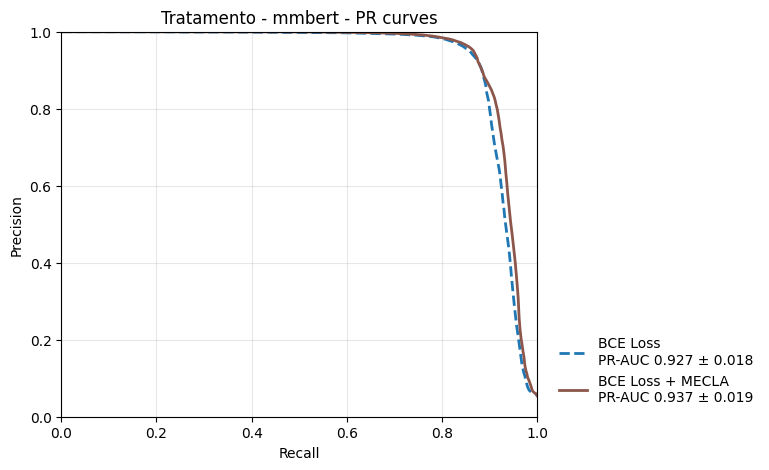

In [3]:
from pathlib import Path
import jsonlines
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Overlapping plots

labels = ['Problema', 'Teste', 'Anatomia', 'Tratamento']

# --- NEW: explicit color mapping ---
colors = {
    'baseline': 'tab:blue',
    'exp_1_mecla': 'tab:orange',
    'exp_2_mecla': 'tab:red',
    'exp_3_mecla': 'tab:green',
    'exp_5_mecla': 'tab:purple',
    'mecla': 'tab:brown',
}

experiments_names = {
    'baseline': 'BCE Loss',
    'exp_1_mecla': 'BCE Loss + MECLA',
    'mecla': 'BCE Loss + MECLA',
    'exp_2_mecla': 'BCE Loss + Pairwise MECLA',
    'exp_3_mecla': 'BCE + Grouped Softmax',
    'exp_5_mecla': 'BCE + Weighted Grouped Softmax',
}

line_styles = {
    'baseline': '--',
    'exp_1_mecla': '-',
    'exp_2_mecla': '-',
    'exp_3_mecla': '-',
    'exp_5_mecla': '-',
    'mecla': '-',
}

legend_fontsize = 10  # <- adjust as you like

for model in models:
    for label in labels:
        fig, ax = plt.subplots(figsize=(8, 5))

        for exp in experiments:
            experiments_to_evaluate = list(Path(f'experiments/nestedclinbr_{model}_{exp}').glob('**/metrics_*.jsonl'))
            metrics = []
            for experiment_path in experiments_to_evaluate:
                with jsonlines.open(experiment_path) as reader:
                    for obj in reader:
                        metrics.append(obj)

            df = pd.DataFrame(metrics)

            pr_aucs = np.asarray(
                [df["threshold_map"][i][label]["pr_auc"]
                 for i in range(len(df["threshold_map"]))]
            )

            curve_label = (
                f"{experiments_names[exp]}\n"
                f"PR-AUC {pr_aucs.mean():.3f} ± {pr_aucs.std():.3f}"
            )

            precisions = [
                df["threshold_map"][i][label]["precision"]
                for i in range(len(df["threshold_map"]))
            ]
            recalls = [
                df["threshold_map"][i][label]["recall"]
                for i in range(len(df["threshold_map"]))
            ]

            recall_grid, mean_p, lower, upper = _compute_pr_mean_std(
                precisions,
                recalls,
            )

            # --- MODIFIED plot call ---
            ax.plot(
                recall_grid,
                mean_p,
                linewidth=2,
                color=colors[exp],
                label=curve_label,
                linestyle='dashed' if exp == 'baseline' else 'solid',
            )

        ax.set_xlabel("Recall")
        ax.set_ylabel("Precision")
        ax.set_xlim(0, 1)
        ax.set_ylim(0, 1)
        ax.grid(True, alpha=0.3)

        # --- NEW: legend outside, bottom-right ---
        ax.legend(
            loc="lower left",
            bbox_to_anchor=(1.02, 0),
            fontsize=legend_fontsize,
            frameon=False,
        )

        # --- NEW: make room for legend ---
        fig.subplots_adjust(right=0.72)

        ax.set_title(f'{label} - {model} - PR curves')
        plt.show()


    eval_loss  eval_best_threshold  eval_macro_precision  eval_macro_recall  \
0    0.034849                 0.05              0.664225           0.579416   
1    0.045181                 0.03              0.550764           0.520629   
2    0.034822                 0.03              0.646132           0.592266   
3    0.034134                 0.06              0.653372           0.589603   
4    0.035899                 0.05              0.638622           0.578177   
5    0.039136                 0.04              0.566454           0.550153   
6    0.031688                 0.05              0.658260           0.591685   
7    0.036378                 0.09              0.655163           0.504893   
8    0.039233                 0.04              0.632781           0.528775   
9    0.032147                 0.06              0.674469           0.585572   
10   0.035456                 0.10              0.684306           0.521493   
11   0.032122                 0.04              0.65

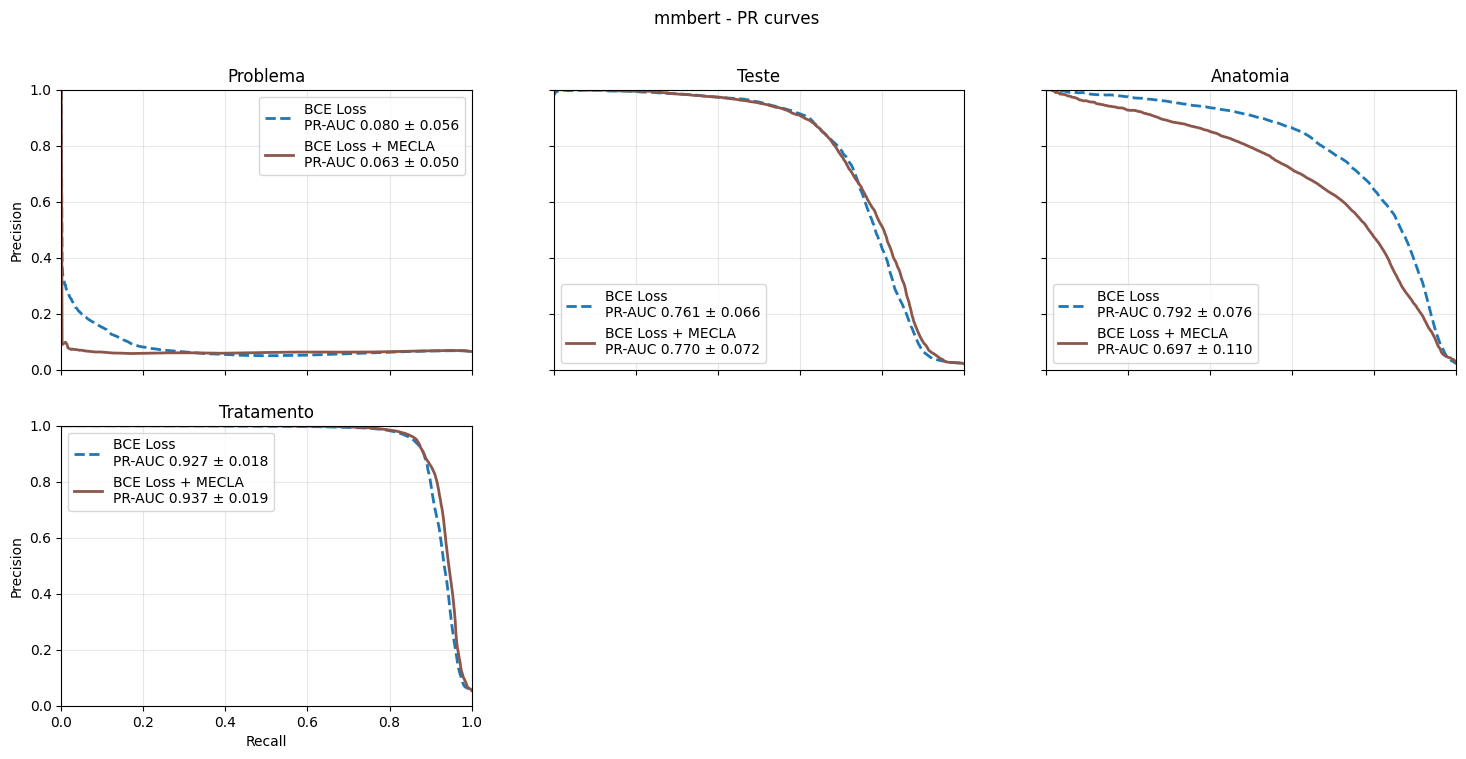

In [6]:
from pathlib import Path
import math
import jsonlines
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

legend_fontsize = 10

MAX_COLS = 3

for model in models:
    n_labels = len(labels)
    ncols = min(MAX_COLS, n_labels)
    nrows = math.ceil(n_labels / ncols)

    fig, axes = plt.subplots(
        nrows=nrows,
        ncols=ncols,
        figsize=(6 * ncols, 4 * nrows),
        sharex=True,
        sharey=True,
    )

    # Make axes always iterable
    axes = np.array(axes).reshape(-1)

    for i, label in enumerate(labels):
        ax = axes[i]

        for exp in experiments:
            experiments_to_evaluate = list(Path(f'experiments/nestedclinbr_{model}_{exp}').glob('**/metrics_*.jsonl'))
            metrics = []
            for experiment_path in experiments_to_evaluate:
                with jsonlines.open(experiment_path) as reader:
                    for obj in reader:
                        metrics.append(obj)

            df = pd.DataFrame(metrics)
            print(df)

            pr_aucs = np.asarray(
                [df["threshold_map"][j][label]["pr_auc"] for j in range(len(df["threshold_map"]))]
            )

            curve_label = (
                f"{experiments_names[exp]}\n"
                f"PR-AUC {pr_aucs.mean():.3f} ± {pr_aucs.std():.3f}"
            )

            precisions = [df["threshold_map"][j][label]["precision"] for j in range(len(df["threshold_map"]))]
            recalls = [df["threshold_map"][j][label]["recall"] for j in range(len(df["threshold_map"]))]

            recall_grid, mean_p, lower, upper = _compute_pr_mean_std(precisions, recalls)

            ax.plot(
                recall_grid,
                mean_p,
                linewidth=2,
                color=colors[exp],
                linestyle=line_styles[exp],
                label=curve_label,
            )
            ax.legend(fontsize=legend_fontsize)

        ax.set_title(label)
        ax.set_xlim(0, 1)
        ax.set_ylim(0, 1)
        ax.grid(True, alpha=0.3)

        # Only put axis labels on left/bottom to keep the grid clean
        if i % ncols == 0:
            ax.set_ylabel("Precision")
        if i // ncols == nrows - 1:
            ax.set_xlabel("Recall")

    # Turn off any unused subplots (if labels not multiple of ncols)
    for k in range(n_labels, len(axes)):
        axes[k].axis("off")


    fig.suptitle(f"{model} - PR curves", y=0.98)
    plt.show()
